# Lifetime GDP Growth

Charts mean annual GDP growth over people's lifetime by birth year for selected countries.

| Data                          | Source                                                                                                           | Accessed       |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------- | -------------- |
| Annual GDP growth per country | [World Bank](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG?end=2024&locations=DE&start=1961&view=chart) | 16 March, 2026 |

Inspired by this [Economist chart](https://www.economist.com/britain/2026/03/05/britains-class-politics-is-back-with-a-green-twist).



In [47]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm

In [2]:
updated = "03/16/2026"
data = {
    "gdp-growth": pd.read_csv(
        "./data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.csv",
        skiprows=4,
    )
}

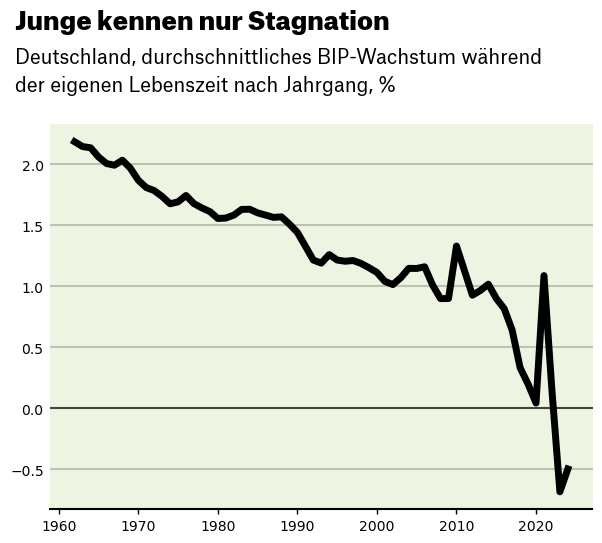

In [196]:
countries = ["Germany"]

d = (
    data["gdp-growth"]
    .loc[data["gdp-growth"]["Country Name"].isin(countries)]
    .melt(
        id_vars=[
            "Country Name",
            "Country Code",
            "Indicator Name",
            "Indicator Code",
            "Unnamed: 70",
        ]
    )[["Country Name", "Country Code", "variable", "value"]]
    .rename(columns={"variable": "year", "Country Name": "country_name"})
)

d["year"] = d["year"].apply(pd.to_datetime)
d["value"] = d["value"].astype(float)

res = []

for y in range(1962, 2025):
    for c in countries:
        avg_growth = d.loc[(d["country_name"] == c) & (d["year"] >= f"{y}")][
            "value"
        ].mean()
        res.append({"year": y, "avg_growth": avg_growth, "country": c})

result = (
    pd.DataFrame(res).set_index(["year"]).pivot(columns="country", values="avg_growth")
)

fig, ax = plt.subplots(figsize=(7, 5))
graphik_bold = fm.FontProperties(fname="../fonts/ATLASGROTESK Black.OTF")
graphik_regular = fm.FontProperties(fname="../fonts/ATLASGROTESK REGULAR.OTF")

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
result.plot(ax=ax, linewidth=5, color="black", legend=False)

ax.set_yticks([-0.5, 0, 0.5, 1, 1.5, 2])
ax.grid(axis="y", color="#000000", alpha=0.2, zorder=10, linewidth=1.5)
ax.text(
    x=0.075,
    y=1.07,
    s="Junge kennen nur Stagnation",
    transform=fig.transFigure,
    ha="left",
    fontsize=18,
    alpha=1,
    fontproperties=graphik_bold,
    linespacing=5,
)
ax.text(
    x=0.075,
    y=0.945,
    s="Deutschland, durchschnittliches BIP-Wachstum während\nder eigenen Lebenszeit nach Jahrgang, %",
    transform=fig.transFigure,
    ha="left",
    fontsize=14,
    linespacing=1.5,
    alpha=1,
    fontproperties=graphik_regular,
)

ax.axhline(y=0, color="#555", lw=1.5, zorder=0)
ax.set_facecolor("#EDF4E1")
ax.yaxis.set_tick_params(pad=1, labelsize=10, bottom=False)
ax.xaxis.set_tick_params(width=1)
ax.set_xlabel(None)


plt.show()